In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, auc
from sklearn.datasets import make_classification
from sklearn.neural_network import MLPClassifier

# Load the dataset
df = pd.read_csv('combined_cleaned_cardio_data.csv')

# Explore the first few rows
print(df.head())

# Check for missing values
print(df.isnull().sum())

# Summary statistics
print(df.describe())
df.info()

   id        age  gender  height  weight  ap_hi  ap_lo        cholesterol  \
0   0  50.357290    male     168    62.0    110     80             normal   
1   1  55.381246  female     156    85.0    140     90  well above normal   
2   2  51.627652  female     165    64.0    130     70  well above normal   
3   3  48.249144    male     169    82.0    150    100             normal   
4   4  47.841205  female     156    56.0    100     60             normal   

     gluc  smoke   alco  active  cardio        bmi age_group  \
0  normal  False  False    True   False  21.967120     50-59   
1  normal  False  False    True    True  34.927679     50-59   
2  normal  False  False   False    True  23.507805     50-59   
3  normal  False  False    True    True  28.710479     40-49   
4  normal  False  False   False   False  23.011177     40-49   

            bp_category  
0              elevated  
1  stage 2 hypertension  
2  stage 1 hypertension  
3  stage 2 hypertension  
4                norma

In [2]:
# Select features and target
features = ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'bmi']
X = df[features]
y = df['cardio']

# Convert categorical variables (if needed)
X = pd.get_dummies(X, columns=['gender', 'cholesterol', 'gluc'], drop_first=True)

# Split data into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [3]:
# Test which alpha value will aquire the highest accuracy
# Warning: This code will take about an hour to run. You may let it run in the background.
alpha_values = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0]
accuracies = []

for alpha in alpha_values:
    mlp = MLPClassifier(hidden_layer_sizes=(100,), alpha=alpha, max_iter=1000, random_state=42)
    mlp.fit(X_train_scaled, y_train)
    y_pred = mlp.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)
    print(f"alpha={alpha:.5f}, Accuracy: {accuracy:.3f}")

alpha=0.00001, Accuracy: 0.738
alpha=0.00010, Accuracy: 0.737
alpha=0.00100, Accuracy: 0.737
alpha=0.01000, Accuracy: 0.739
alpha=0.10000, Accuracy: 0.740
alpha=1.00000, Accuracy: 0.735


In [4]:
# Test which hidden layer size will acquire the most accuracy
# Warning: This code will take about a few hours to run, consider playing a game while it runs.
layer_sizes = [(50,), (100,), (200,), (50, 50),(100, 50), (100, 100), (150, 100), (150, 150), (200, 150), (200, 200), (250, 200), (250, 250), (300, 300), (50, 25, 10), (100, 50, 25), (100, 100, 50), (150, 100, 50), (200, 150, 100), (200, 200, 150), (200, 200, 200), (250, 200, 200),(250,250,200),(250,250,250)]
accuracies = []

for layers in layer_sizes:
    mlp = MLPClassifier(hidden_layer_sizes=layers, max_iter=1000, random_state=42, alpha = 0.1)
    mlp.fit(X_train_scaled, y_train)
    y_pred = mlp.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)
    print(f"hidden_layer_sizes={layers}, Accuracy: {accuracy:.3f}")

hidden_layer_sizes=(50,), Accuracy: 0.738
hidden_layer_sizes=(100,), Accuracy: 0.740
hidden_layer_sizes=(200,), Accuracy: 0.738
hidden_layer_sizes=(50, 50), Accuracy: 0.742
hidden_layer_sizes=(100, 50), Accuracy: 0.739
hidden_layer_sizes=(100, 100), Accuracy: 0.739
hidden_layer_sizes=(150, 100), Accuracy: 0.742
hidden_layer_sizes=(150, 150), Accuracy: 0.740
hidden_layer_sizes=(200, 150), Accuracy: 0.739
hidden_layer_sizes=(200, 200), Accuracy: 0.738
hidden_layer_sizes=(250, 200), Accuracy: 0.741
hidden_layer_sizes=(250, 250), Accuracy: 0.743
hidden_layer_sizes=(300, 300), Accuracy: 0.742
hidden_layer_sizes=(50, 25, 10), Accuracy: 0.740
hidden_layer_sizes=(100, 50, 25), Accuracy: 0.739
hidden_layer_sizes=(100, 100, 50), Accuracy: 0.739
hidden_layer_sizes=(150, 100, 50), Accuracy: 0.740
hidden_layer_sizes=(200, 150, 100), Accuracy: 0.739
hidden_layer_sizes=(200, 200, 150), Accuracy: 0.737
hidden_layer_sizes=(200, 200, 200), Accuracy: 0.741
hidden_layer_sizes=(250, 200, 200), Accuracy: 0.

In [3]:
# Create classifier according to most accurate alpha and size
clf = MLPClassifier(hidden_layer_sizes=(250, 250), max_iter=1000, alpha=0.1, random_state=42).fit(X_train_scaled, y_train)

In [4]:
# Fit classifier in training set
clf.fit(X_train_scaled, y_train)

MLPClassifier(alpha=0.1, hidden_layer_sizes=(250, 250), max_iter=1000,
              random_state=42)

In [5]:
# Predict using classifier
y_pred = clf.predict(X_test_scaled)

Accuracy: 0.7428571428571429
              precision    recall  f1-score   support

       False       0.73      0.76      0.75      6988
        True       0.75      0.72      0.74      7012

    accuracy                           0.74     14000
   macro avg       0.74      0.74      0.74     14000
weighted avg       0.74      0.74      0.74     14000


True Positives(TP) =  5335

True Negatives(TN) =  5065

False Positives(FP) =  1947

False Negatives(FN) =  1653


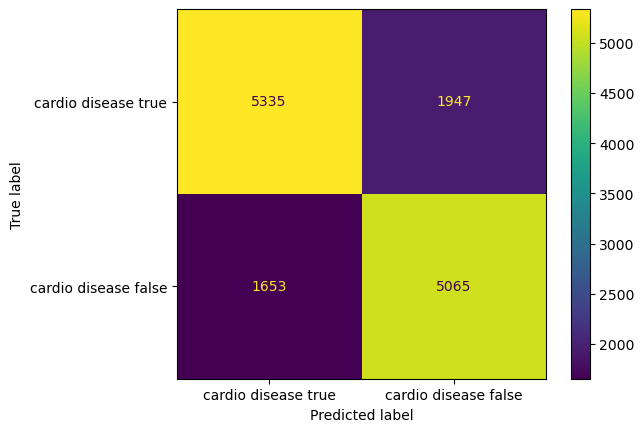

In [6]:
# Get accuracy score and confusion matrix
cm = confusion_matrix(y_pred, y_test)
print("Accuracy:", accuracy_score(y_pred, y_test))
print(classification_report(y_test, y_pred))
labels = ["cardio disease true", "cardio disease false"]
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot()
print('\nTrue Positives(TP) = ', cm[0,0])

print('\nTrue Negatives(TN) = ', cm[1,1])

print('\nFalse Positives(FP) = ', cm[0,1])

print('\nFalse Negatives(FN) = ', cm[1,0])